<a href="https://colab.research.google.com/github/VaniaFelicia/Text-Preprocessing-Billboard-Hot-100-dan-iTunes-API/blob/main/Text_Preprocessing_(Chapter%204).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TUGAS TEXT PREPROCESSING PREMROSESAN TEKS**

Eifellyne Putri Widayanto (011)
Vania Felicia Gita Wulandari (058)

Preprocessing teks hasil scraping sebelumnya (Billboard Hot 100 dan iTunes API)

 Scraping Web Scraping (HTML) - Billboard Hot 100

In [66]:
import warnings
warnings.filterwarnings(action='ignore')
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [67]:
url = 'https://www.billboard.com/charts/hot-100/'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

In [68]:
response = requests.get(url, headers=headers)
response.status_code

200

In [69]:
ds = BeautifulSoup(response.text, 'html.parser')
chart_items = ds.find_all('ul', class_='o-chart-results-list-row')
len(chart_items)

100

In [70]:
songs, artists = [], []
for item in chart_items:
  title_elem = item.find('h3', id='title-of-a-story')
  artist_elem = title_elem.find_next('span') if title_elem else None
  if title_elem and artist_elem:
    songs.append(title_elem.text.strip())
    artists.append(artist_elem.text.strip())
len(songs), len(artists)

(100, 100)

In [71]:
df_billboard = pd.DataFrame({
  'Peringkat': range(1, len(songs) + 1),
  'Judul Lagu': songs,
  'Penyanyi': artists
})
df_billboard.head()

,Peringkat,Judul Lagu,Penyanyi
0,1,Choosin' Texas,Ella Langley
1,2,Boston,Stella Lefty
2,3,Been By Now,Morgan Wallen
3,4,Hate That I Made You Love Me,Ariana Grande
4,5,Dracula,Tame Impala & JENNIE


API Request (JSON) - iTunes

In [72]:
query_artist = 'Taylor Swift'
max_result = 20
url_api = f"https://itunes.apple.com/search?term={query_artist}&limit={max_result}&entity=song"

In [73]:
response = requests.get(url_api)
response.status_code

200

In [74]:
data_itunes = response.json()
print("Keys utama:", data_itunes.keys())
print("Total data:", data_itunes.get('resultCount'))

Keys utama: dict_keys(['resultCount', 'results'])
Total data: 20


In [75]:
song_titles, artist_names, album_names = [], [], []
for item in data_itunes.get('results', []):
  song_titles.append(item.get('trackName'))
  artist_names.append(item.get('artistName'))
  album_names.append(item.get('collectionName'))
len(song_titles), len(artist_names), len(album_names)

(20, 20, 20)

In [76]:
df_itunes = pd.DataFrame({
  'No': range(1, len(song_titles) + 1),
  'Judul Lagu': song_titles,
  'Penyanyi': artist_names,
  'Album': album_names
})
df_itunes.head()

,No,Judul Lagu,Penyanyi,Album
0,1,Patient Zero,Taylor Swift,The Life of a Showgirl: The Encore
1,2,Cleveland!,Taylor Swift,The Life of a Showgirl: The Encore
2,3,Pink Clouding,Taylor Swift,The Life of a Showgirl: The Encore
3,4,Babylon,Taylor Swift,The Life of a Showgirl: The Encore
4,5,"I Knew It, I Knew You (From ""Toy Story 5"")",Taylor Swift,"I Knew It, I Knew You (From ""Toy Story 5"") - S..."


Mixing Data Billboard & iTunes

In [77]:
df = pd.concat([
  df_billboard[['Judul Lagu', 'Penyanyi']].assign(Sumber='Billboard Hot 100'),
  df_itunes[['Judul Lagu', 'Penyanyi']].assign(Sumber='iTunes API'),
], ignore_index=True)
df.rename(columns={'Judul Lagu': 'text'}, inplace=True)
df.head()

,text,Penyanyi,Sumber
0,Choosin' Texas,Ella Langley,Billboard Hot 100
1,Boston,Stella Lefty,Billboard Hot 100
2,Been By Now,Morgan Wallen,Billboard Hot 100
3,Hate That I Made You Love Me,Ariana Grande,Billboard Hot 100
4,Dracula,Tame Impala & JENNIE,Billboard Hot 100


In [78]:
df = df[~((df['Sumber'] == 'iTunes API') & (df['Penyanyi'] != 'Taylor Swift'))]
len(df)

118

In [79]:
df = df.drop_duplicates(subset=['text', 'Sumber']).reset_index(drop=True)
df.head()

,text,Penyanyi,Sumber
0,Choosin' Texas,Ella Langley,Billboard Hot 100
1,Boston,Stella Lefty,Billboard Hot 100
2,Been By Now,Morgan Wallen,Billboard Hot 100
3,Hate That I Made You Love Me,Ariana Grande,Billboard Hot 100
4,Dracula,Tame Impala & JENNIE,Billboard Hot 100


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      113 non-null    object
 1   Penyanyi  113 non-null    object
 2   Sumber    113 non-null    object
dtypes: object(3)
memory usage: 2.8+ KB


worldcloud before

In [81]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

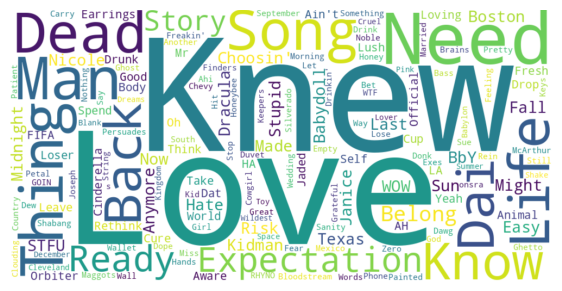

In [82]:
text = ' '.join(df['text'].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=500).generate(text)
plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**Preprocessing Teks**



remove HTML tags

In [83]:
import re
def remove_html(text):
  html_pattern = re.compile('<.*?>')
  return html_pattern.sub(r'', str(text))
text = """<div>
<h1>Shake It Off</h1>
<p>Taylor Swift</p>
<a href="https://www.billboard.com/">Billboard</a>
</div>"""
hasil_ht = remove_html(text)
print(hasil_ht)


Shake It Off
Taylor Swift
Billboard



remove hashtag

In [84]:
def remove_hashtag(text):
  return re.sub(r'#\w+', '', text)
text = "Love Story is the best #TaylorSwift #Swifties"
hasil_hs = remove_hashtag(text)
print(hasil_hs)

Love Story is the best  


lower casing

In [85]:
def lower_casing(text):
  return str.lower(text)
text = "Hate That I Made You Love Me - ARIANA GRANDE"
hasil_cf = lower_casing(text)
print(hasil_cf)

hate that i made you love me - ariana grande


remove URL, HTTP, and e-mail

In [86]:
def remove_urls(text):
  text = re.sub(r'https?://\S+', '', str(text)) # hyperlink
  text = re.sub(r'www\S+', '', text)            # www
  text = re.sub(r'\S+@\S+', '', text)           # email
  return text
text = "dracula tame impala, info di https://www.billboard.com atau www.billboard.com, kontak aini@yahoo.com"
hasil_rl = remove_urls(text)
print(hasil_rl)

dracula tame impala, info di  atau  kontak 


remove punctuations

In [87]:
def remove_punctuation_list(text):
  text = re.sub(r'(:\)|:-\)|:D|:-D|;\)|;-\))', '', text, flags=re.IGNORECASE)
  text = re.sub(r'(:\(|:-\()', '', text)
  text = re.sub(r'(:v|:-v)', '', text, flags=re.IGNORECASE)
  text = re.sub(r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~’‘“”…]', ' ', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text
text = "...ready for it? let’s get married :D choosin' texas!!"
hasil_rp = remove_punctuation_list(text)
print(hasil_rp)

ready for it let s get married choosin texas


removal of emojis

In [88]:
!pip install demoji

In [89]:
import demoji
def remove_emoji(text):
  cleaned_text = demoji.replace(text, repl="")
  return cleaned_text
text = "cruel summer 🔥 wildest dreams 💖"
hasil_rem = remove_emoji(text)
print(hasil_rem)

cruel summer  wildest dreams 


stemmer

In [90]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()
def stem_kalimat(text):
  return " ".join([ps.stem(word) for word in str(text).split()])
text = "wildest dreams texas loving running"
hasil_stem = stem_kalimat(text)
print(hasil_stem)

wildest dream texa love run


remove stopword

In [91]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
sw = set(stopwords.words('english'))
def remove_stopwords(text):
  return " ".join([word for word in str(text).split() if word not in sw])
text = "hate that i made you love me"
hasil_st = remove_stopwords(text)
print(hasil_st)

hate made love


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


remove html tags

In [92]:
df['rm_html'] = df['text'].apply(remove_html)
df[['text', 'rm_html']].head()

,text,rm_html
0,Choosin' Texas,Choosin' Texas
1,Boston,Boston
2,Been By Now,Been By Now
3,Hate That I Made You Love Me,Hate That I Made You Love Me
4,Dracula,Dracula


remove hashtag

In [93]:
df['rm_hashtag'] = df['rm_html'].apply(remove_hashtag)
df[['rm_html', 'rm_hashtag']].head()

,rm_html,rm_hashtag
0,Choosin' Texas,Choosin' Texas
1,Boston,Boston
2,Been By Now,Been By Now
3,Hate That I Made You Love Me,Hate That I Made You Love Me
4,Dracula,Dracula


lower casing

In [94]:
df['lower_case'] = df['rm_hashtag'].apply(lower_casing)
df[['rm_hashtag', 'lower_case']].head()

,rm_hashtag,lower_case
0,Choosin' Texas,choosin' texas
1,Boston,boston
2,Been By Now,been by now
3,Hate That I Made You Love Me,hate that i made you love me
4,Dracula,dracula


remove URL, HTTP, and e-mail

In [95]:
df['rm_url'] = df['lower_case'].apply(remove_urls)
df[['lower_case', 'rm_url']].head()

,lower_case,rm_url
0,choosin' texas,choosin' texas
1,boston,boston
2,been by now,been by now
3,hate that i made you love me,hate that i made you love me
4,dracula,dracula


remove punctuations

In [96]:
df['rm_punc'] = df['rm_url'].apply(remove_punctuation_list)
df[['rm_url', 'rm_punc']].head()

,rm_url,rm_punc
0,choosin' texas,choosin texas
1,boston,boston
2,been by now,been by now
3,hate that i made you love me,hate that i made you love me
4,dracula,dracula


removal of emojis

In [97]:
df['rm_emoji'] = df['rm_punc'].apply(remove_emoji)
df[['rm_punc', 'rm_emoji']].head()

,rm_punc,rm_emoji
0,choosin texas,choosin texas
1,boston,boston
2,been by now,been by now
3,hate that i made you love me,hate that i made you love me
4,dracula,dracula


stemmer

In [98]:
df['stem'] = df['rm_emoji'].apply(lambda x: stem_kalimat(x) if isinstance(x, str) else '')
df[['rm_emoji', 'stem']].head()

,rm_emoji,stem
0,choosin texas,choosin texa
1,boston,boston
2,been by now,been by now
3,hate that i made you love me,hate that i made you love me
4,dracula,dracula


remove stopword

In [99]:
df['rm_stopwords'] = df['stem'].apply(remove_stopwords)
df[['stem', 'rm_stopwords']].head()

,stem,rm_stopwords
0,choosin texa,choosin texa
1,boston,boston
2,been by now,
3,hate that i made you love me,hate made love
4,dracula,dracula


wordcloud after

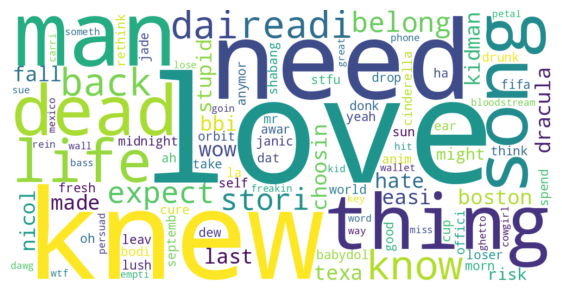

In [100]:
text = ' '.join(df['rm_stopwords'].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=100).generate(text)
plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

rename ke prepro

In [101]:
df.rename(columns={'rm_stopwords': 'prepro'}, inplace=True)
df[['Sumber', 'text', 'prepro']]

,Sumber,text,prepro
0,Billboard Hot 100,Choosin' Texas,choosin texa
1,Billboard Hot 100,Boston,boston
2,Billboard Hot 100,Been By Now,
3,Billboard Hot 100,Hate That I Made You Love Me,hate made love
4,Billboard Hot 100,Dracula,dracula
...,...,...,...
108,iTunes API,Blank Space,blank space
109,iTunes API,Wildest Dreams,wildest dream
110,iTunes API,The Man,man
111,iTunes API,Lover,lover


cek baris kosong

In [102]:
print('Baris kosong setelah preprocessing:', (df['prepro'].str.strip() == '').sum())

Baris kosong setelah preprocessing: 4


delete baris kosong

In [103]:
df = df[df['prepro'].str.strip() != ''].reset_index(drop=True)
df[['Sumber', 'text', 'prepro']]

,Sumber,text,prepro
0,Billboard Hot 100,Choosin' Texas,choosin texa
1,Billboard Hot 100,Boston,boston
2,Billboard Hot 100,Hate That I Made You Love Me,hate made love
3,Billboard Hot 100,Dracula,dracula
4,Billboard Hot 100,BbY WOW,bbi wow
...,...,...,...
104,iTunes API,Blank Space,blank space
105,iTunes API,Wildest Dreams,wildest dream
106,iTunes API,The Man,man
107,iTunes API,Lover,lover


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        109 non-null    object
 1   Penyanyi    109 non-null    object
 2   Sumber      109 non-null    object
 3   rm_html     109 non-null    object
 4   rm_hashtag  109 non-null    object
 5   lower_case  109 non-null    object
 6   rm_url      109 non-null    object
 7   rm_punc     109 non-null    object
 8   rm_emoji    109 non-null    object
 9   stem        109 non-null    object
 10  prepro      109 non-null    object
dtypes: object(11)
memory usage: 9.5+ KB


save hasil preprocessing

In [105]:
df[['Sumber', 'text', 'prepro']].to_csv('song_preprocessed.csv', index=False)